In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("SuperStoreOrders.csv")

In [4]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [6]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [9]:
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')


In [16]:
df.drop_duplicates(inplace=True)
df['order_date'] = df['order_date'].str.replace('/','-')
df['order_date'] = pd.to_datetime(df['order_date'],format='%d-%m-%Y')
df['ship_date'] = df['ship_date'].str.replace('/','-')
df['ship_date'] = pd.to_datetime(df['ship_date'],format='%d-%m-%Y')
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_weekday'] = df['order_date'].dt.weekday+1
df['order_year_month'] = df['order_date'].dt.strftime('%Y-%m')
df['ship_days'] = (df['ship_date']-df['order_date']).dt.days

df['sales'] = df['sales'].str.replace(',','').astype(float)
df['cost'] = df['sales'] - df['profit']
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,shipping_cost,order_priority,year,order_year,order_month,order_day,order_weekday,order_year_month,ship_days,cost
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,35.46,Medium,2011,2011,1,1,6,2011-01,5,301.860
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,9.72,Medium,2011,2011,1,1,6,2011-01,7,83.964
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,8.17,High,2011,2011,1,1,6,2011-01,4,36.360
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,4.82,High,2011,2011,1,1,6,2011-01,4,71.055
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,4.70,Medium,2011,2011,1,1,6,2011-01,7,76.230


In [17]:
print('The most recent Order Date is:',df['order_date'].max())
print('The first Order Date is:',df['order_date'].min())

The most recent Order Date is: 2014-12-31 00:00:00
The first Order Date is: 2011-01-01 00:00:00


In [18]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year,order_year,order_month,order_day,order_weekday,ship_days,cost
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208,2012.777208,7.522636,15.782960,3.343264,3.969370,217.856701
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,2011.000000,1.000000,1.000000,1.000000,0.000000,0.417200
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,2012.000000,5.000000,8.000000,2.000000,3.000000,26.920000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,2013.000000,8.000000,16.000000,3.000000,4.000000,73.650000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,2014.000000,10.000000,23.000000,5.000000,5.000000,223.077625
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000,2014.000000,12.000000,31.000000,7.000000,7.000000,24449.078400
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931,1.098931,3.300056,8.742164,1.671486,1.729437,430.688693


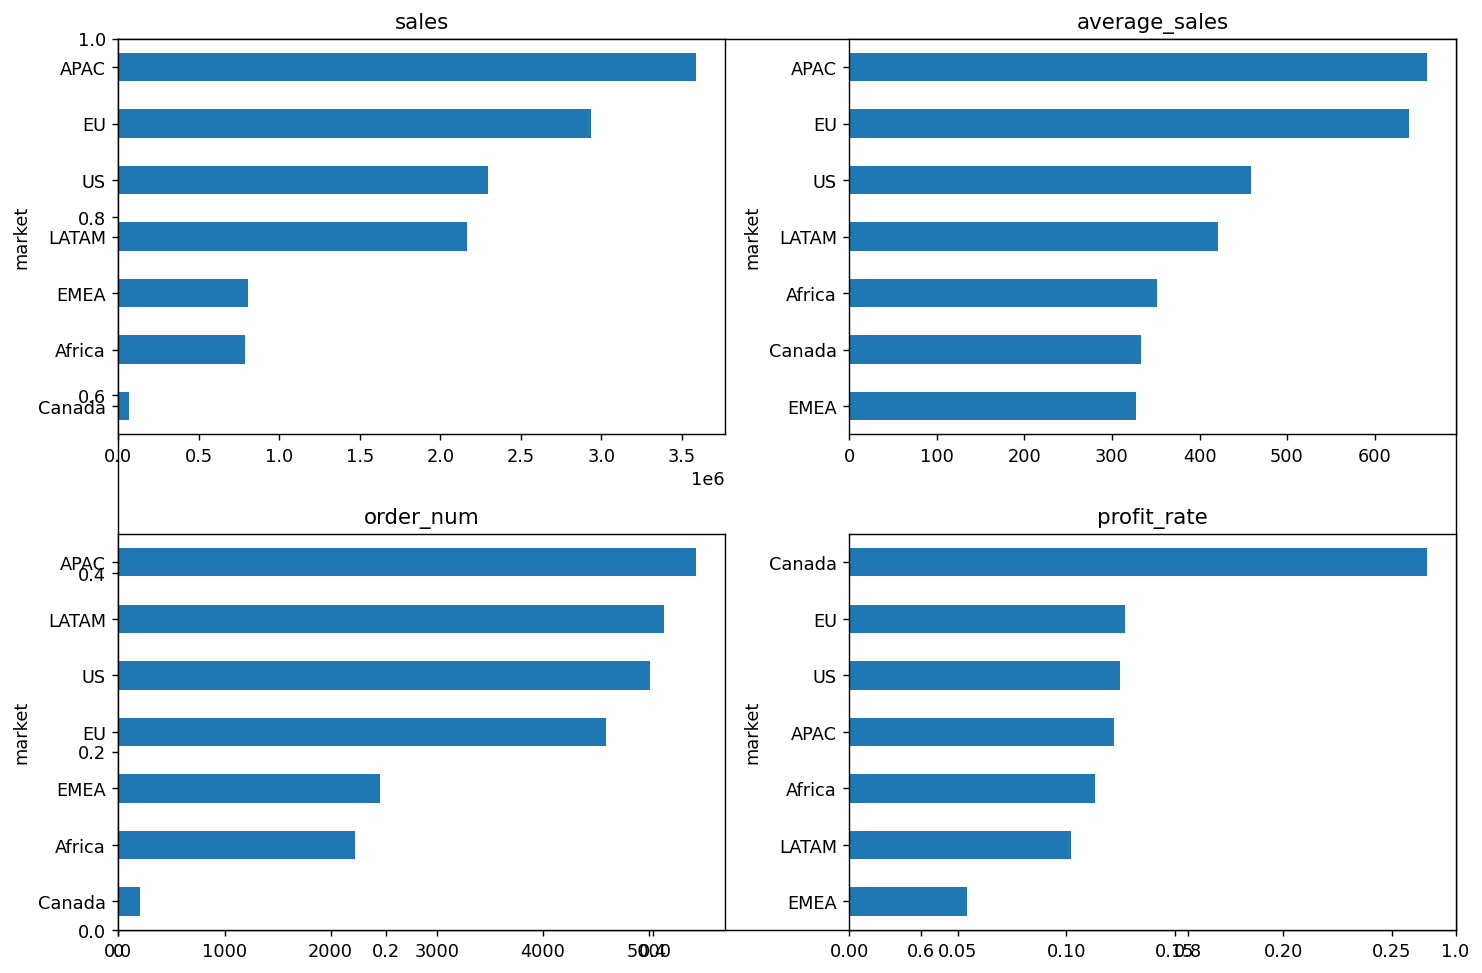

In [19]:
df_market = df.groupby('market').agg({'sales':'sum','order_id':'nunique','profit':'sum'})
df_market['average_sales'] = df_market['sales']/df_market['order_id']
df_market['profit_rate'] = df_market['profit']/df_market['sales']
df_market.rename(columns={'order_id':'order_num'},inplace=True)

fig, ax = plt.subplots(dpi=128, figsize=(12, 8))
for i, col in enumerate(['sales', 'average_sales', 'order_num', 'profit_rate'],1):
    plt.subplot(2,2,i)
    df_market[col].sort_values().plot(kind='barh')
    plt.title(col)
plt.tight_layout()
plt.show()

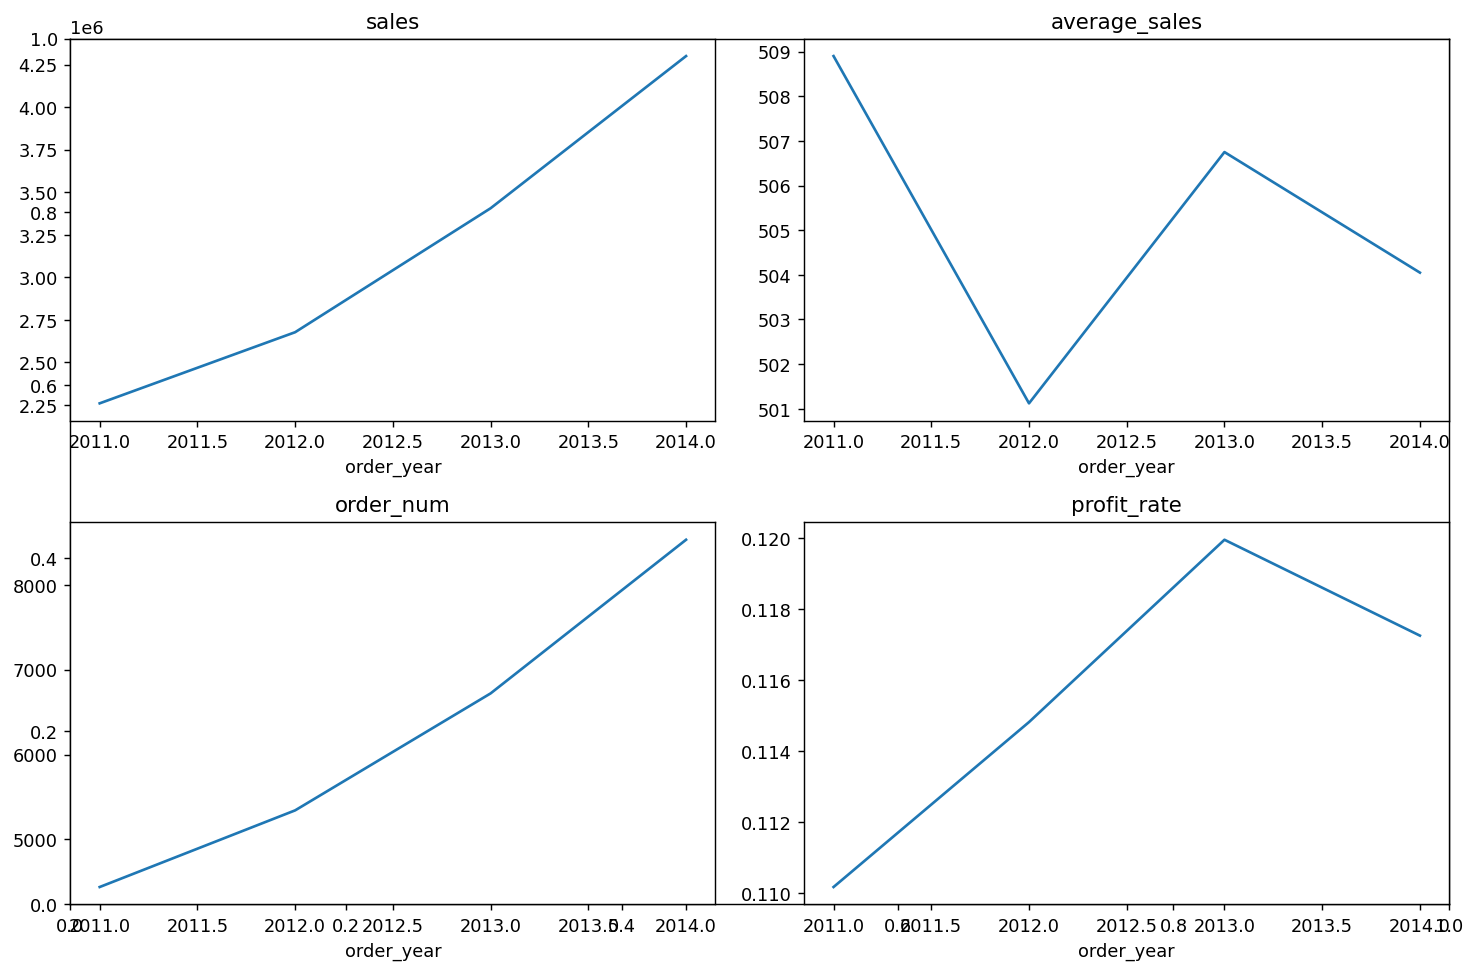

In [20]:
df_year = df.groupby('order_year').agg({'sales': 'sum','order_id': 'nunique','profit': 'sum'})
df_year['average_sales'] = df_year['sales'] / df_year['order_id']
df_year['profit_rate'] = df_year['profit'] / df_year['sales']
df_year.rename(columns={'order_id': 'order_num'}, inplace=True)

fig, ax = plt.subplots(dpi=128, figsize=(12, 8))
for i, col in enumerate(['sales', 'average_sales', 'order_num', 'profit_rate'],1):
    plt.subplot(2,2,i)
    df_year[col].plot(kind='line')
    plt.title(col)
plt.tight_layout()
plt.show()

In [21]:
df_year

,sales,order_num,profit,average_sales,profit_rate
order_year,,,,,
2011,2259511.0,4440,248940.81154,508.898874,0.110175
2012,2677493.0,5343,307415.27910,501.121655,0.114815
2013,3405860.0,6721,408512.76018,506.748996,0.119944
2014,4300041.0,8531,504165.97046,504.048881,0.117247


In [23]:
print('top_products')

top_products


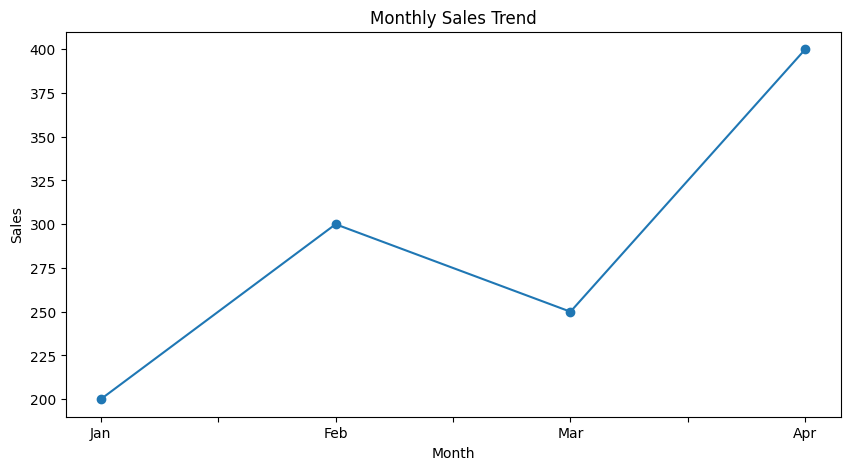

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Example data
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr'],
    'Sales': [200, 300, 250, 400]
}

df = pd.DataFrame(data)

# Create monthly_sales variable
monthly_sales = df.set_index('Month')['Sales']

# Plot graph
plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [35]:
df_year

,sales,order_num,profit,average_sales,profit_rate
order_year,,,,,
2011,2259511.0,4440,248940.81154,508.898874,0.110175
2012,2677493.0,5343,307415.27910,501.121655,0.114815
2013,3405860.0,6721,408512.76018,506.748996,0.119944
2014,4300041.0,8531,504165.97046,504.048881,0.117247


In [38]:
print(df.columns)

Index(['Month', 'Sales'], dtype='str')


In [9]:
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')


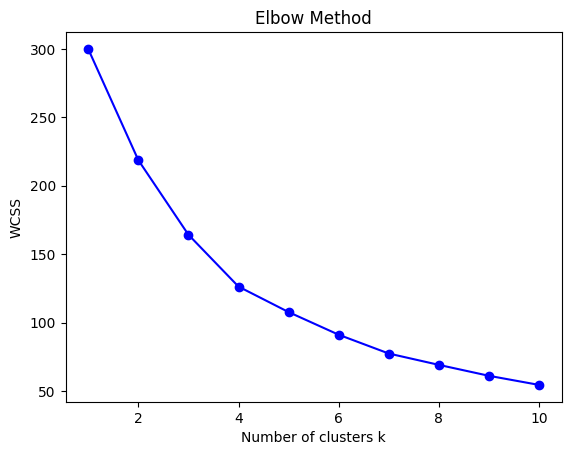

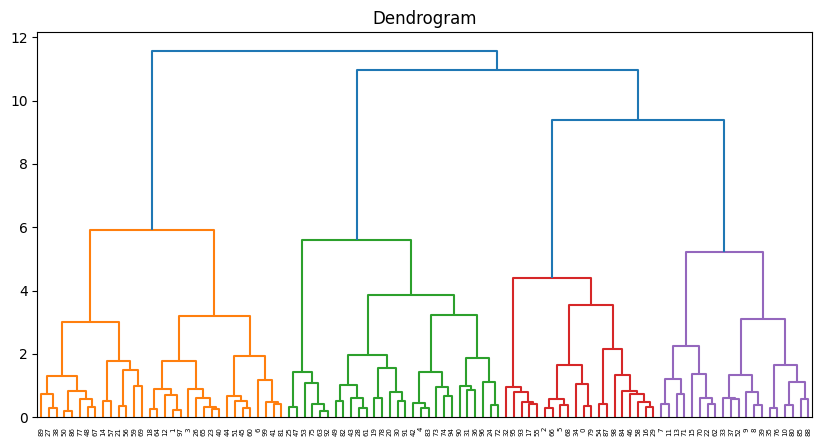

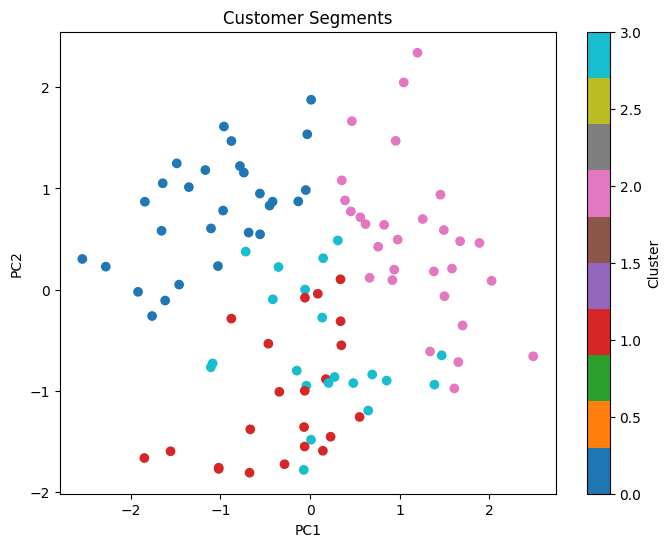

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# Generate sample data
X_array = np.random.rand(100, 3)

# Create DataFrame
df = pd.DataFrame(X_array, columns=[f'feature_{i+1}' for i in range(X_array.shape[1])])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Elbow Method
wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Hierarchical Clustering Dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='tab10')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments')
plt.colorbar(label='Cluster')
plt.show()

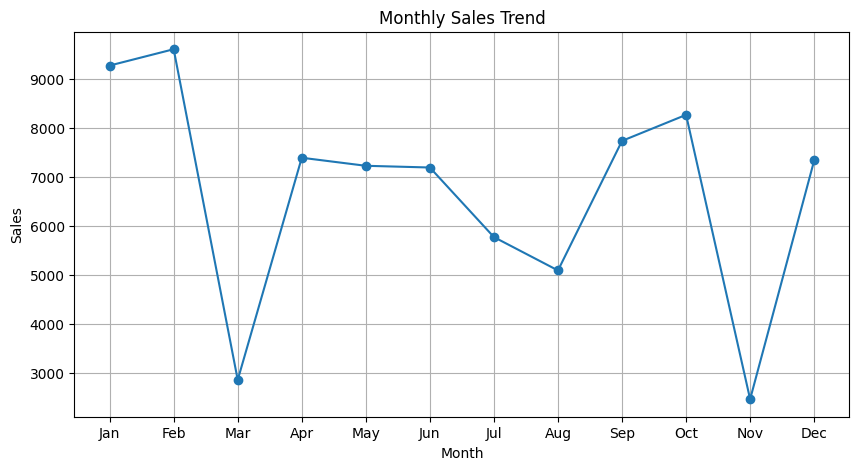

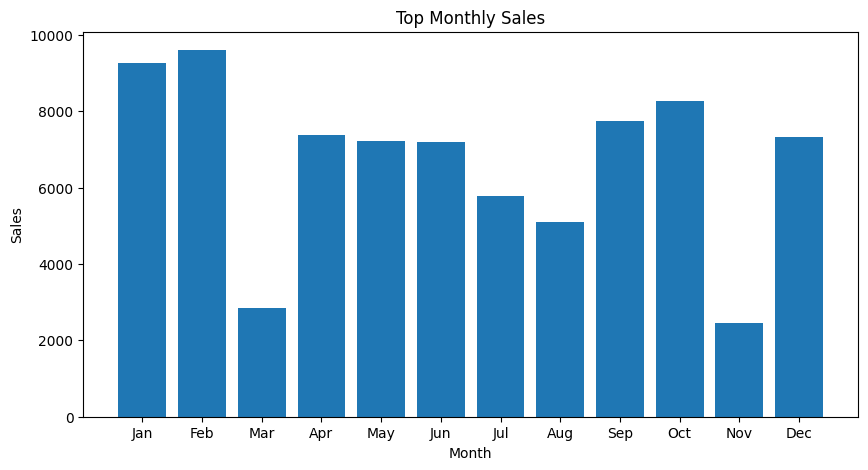

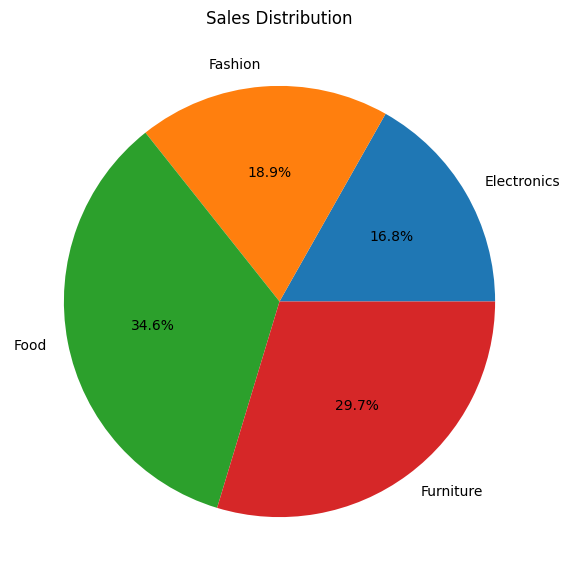

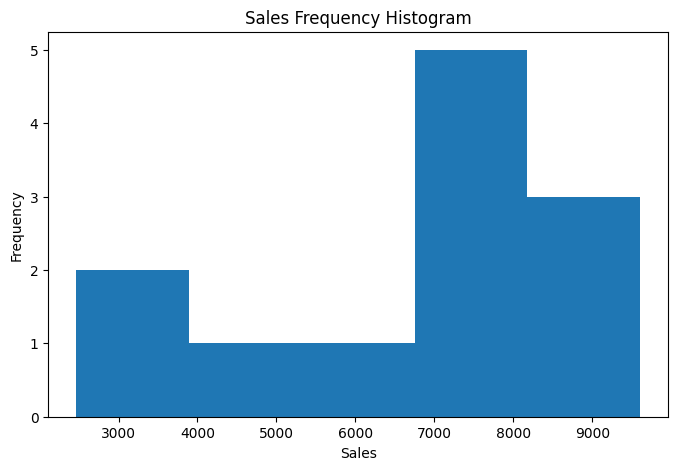

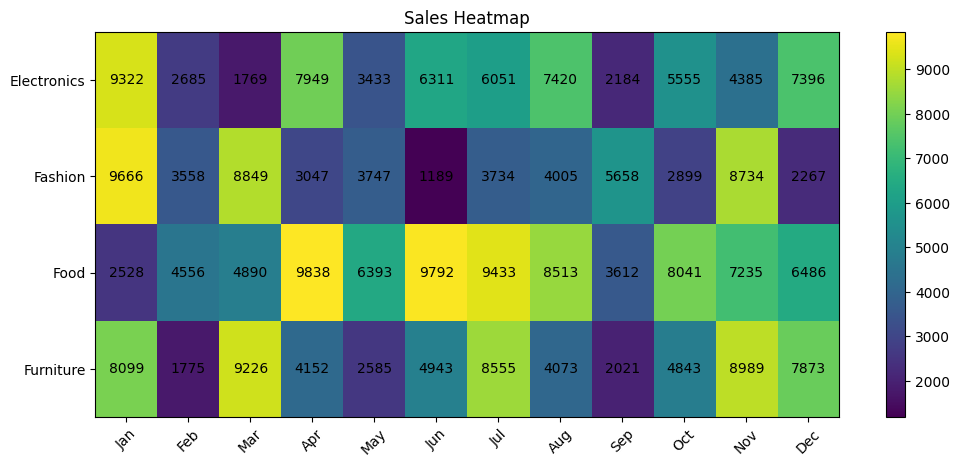

In [ ]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Generate Sample Sales Data

np.random.seed(42)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sales = np.random.randint(2000, 10000, 12)

categories = ['Electronics', 'Fashion', 'Food', 'Furniture']
category_sales = np.random.randint(5000, 20000, 4)

# Create DataFrame
df = pd.DataFrame({
    'Month': months,
    'Sales': sales
})

# 1. Monthly Sales Trend (Line Chart)

plt.figure(figsize=(10,5))

plt.plot(df['Month'], df['Sales'], marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)

plt.show()


# 2. Bar Chart — Top Sales

plt.figure(figsize=(10,5))

plt.bar(df['Month'], df['Sales'])

plt.title('Top Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()


# 3. Pie Chart — Sales Distribution

plt.figure(figsize=(7,7))

plt.pie(
    category_sales,
    labels=categories,
    autopct='%1.1f%%'
)

plt.title('Sales Distribution')

plt.show()

# 4. Histogram — Sales Frequency

plt.figure(figsize=(8,5))

plt.hist(df['Sales'], bins=5)

plt.title('Sales Frequency Histogram')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()


# 5. Heatmap (Advanced)

# Create random sales matrix
heatmap_data = np.random.randint(1000, 10000, (4, 12))

fig, ax = plt.subplots(figsize=(12,5))

im = ax.imshow(heatmap_data, aspect='auto')

# Axis labels
ax.set_xticks(np.arange(len(months)))
ax.set_yticks(np.arange(len(categories)))

ax.set_xticklabels(months)
ax.set_yticklabels(categories)

# Rotate month labels
plt.setp(ax.get_xticklabels(), rotation=45)

# Add values inside heatmap
for i in range(len(categories)):
    for j in range(len(months)):
        text = ax.text(
            j, i,
            heatmap_data[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.title("Sales Heatmap")

plt.colorbar(im)

plt.show()